# 1. Dataset Loading and Setup


In [ ]:
import pandas as pd
!git clone https://github.com/harish-rbuilds/Canteen_DWDM.git
students = pd.read_csv("Canteen_DWDM/raw_data/students.csv")
menu = pd.read_csv("Canteen_DWDM/raw_data/menu_items.csv")
canteens = pd.read_csv("Canteen_DWDM/raw_data/canteens.csv")
transactions = pd.read_csv("Canteen_DWDM/raw_data/transactions.csv")
calendar = pd.read_csv("Canteen_DWDM/raw_data/calendar.csv")
raw_items = pd.read_csv("Canteen_DWDM/raw_data/raw_transaction_items.csv")

Cloning into 'Canteen_DWDM'...
remote: Enumerating objects: 22, done.
remote: Counting objects: 100% (22/22), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 22 (delta 3), reused 22 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (22/22), 1.40 MiB | 4.31 MiB/s, done.
Resolving deltas: 100% (3/3), done.


# 2. Dataset Overview

In [ ]:
datasets = {
    "Students": students,
    "Menu Items": menu,
    "Canteens": canteens,
    "Transactions": transactions,
    "Calendar": calendar,
    "Raw Transaction Items": raw_items
}

for name, df in datasets.items():
    print("=" * 70)
    print(name)
    print("=" * 70)
    print("Rows    :", df.shape[0])
    print("Columns :", df.shape[1])
    print("Column Names:")
    print(df.columns.tolist())
    print("\nFirst 5 Rows:")
    display(df.head())
    print("\n")

Students
Rows    : 2000
Columns : 6
Column Names:
['Student_ID', 'Student_Year', 'Program_Group', 'Residence_Type', 'Gender', 'Loyalty_Status']

First 5 Rows:


,Student_ID,Student_Year,Program_Group,Residence_Type,Gender,Loyalty_Status
0,S0001,3rd Year,IT,Day Scholar,Male,Frequent
1,S0002,1st Year,MECH,Hostel,Male,Regular
2,S0003,2nd Year,CSE,Day Scholar,Male,Frequent
3,S0004,2nd Year,CSE,Day Scholar,Male,Regular
4,S0005,3rd Year,MECH,Day Scholar,Male,Frequent




Menu Items
Rows    : 50
Columns : 8
Column Names:
['Menu_Item_ID', 'Menu_Item_Name', 'Category', 'Cuisine_Type', 'Vegetarian_Flag', 'Unit_Price', 'Preparation_Time_Min', 'Popularity_Level']

First 5 Rows:


,Menu_Item_ID,Menu_Item_Name,Category,Cuisine_Type,Vegetarian_Flag,Unit_Price,Preparation_Time_Min,Popularity_Level
0,I001,Tea,Beverage,Indian,1,20,5,High
1,I002,Coffee,Beverage,Indian,1,30,6,High
2,I003,Samosa,Snack,Indian,1,25,8,High
3,I004,Vada,Snack,Indian,1,25,8,High
4,I005,Puffs,Snack,Indian,1,35,10,High




Canteens
Rows    : 4
Columns : 5
Column Names:
['Canteen_ID', 'Canteen_Name', 'Canteen_Type', 'Opening_Hour', 'Closing_Hour']

First 5 Rows:


...

,Order_ID,Student_ID,Order_Date,Order_Time,Canteen_ID,Meal_Period,Payment_Method,Exam_Period,Holiday_Flag,Special_Event_Flag
0,O000001,S0734,2026-01-01,15:00:00,C04,Snacks,Card,0,0,0
1,O000002,S1098,2026-01-01,20:03:00,C02,Dinner,Cash,0,0,0
2,O000003,S0439,2026-01-01,14:06:00,C01,Lunch,Card,0,0,0
3,O000004,S1649,2026-01-01,14:09:00,C04,Lunch,UPI,0,0,0
4,O000005,S1623,2026-01-01,17:12:00,C01,Snacks,UPI,0,0,0




Calendar
Rows    : 365
Columns : 13
Column Names:
['Date', 'Date_ID', 'Year', 'Month', 'Month_Name', 'Quarter', 'Week', 'Day', 'Day_Name', 'Is_Weekend', 'Exam_Period', 'Holiday_Flag', 'Special_Event_Flag']

First 5 Rows:


,Date,Date_ID,Year,Month,Month_Name,Quarter,Week,Day,Day_Name,Is_Weekend,Exam_Period,Holiday_Flag,Special_Event_Flag
0,1/1/2026,1,2026,1,January,Q1,1,1,Thursday,0,0,0,0
1,1/2/2026,2,2026,1,January,Q1,1,2,Friday,0,0,0,0
2,1/3/2026,3,2026,1,January,Q1,1,3,Saturday,1,0,0,0
3,1/4/2026,4,2026,1,January,Q1,1,4,Sunday,1,0,1,0
4,1/5/2026,5,2026,1,January,Q1,2,5,Monday,0,0,0,0




Raw Transaction Items
Rows    : 83283
Columns : 6
Column Names:
['Order_ID', 'Menu_Item_ID', 'Quantity', 'Unit_Price', 'Discount_Percent', 'Total_Amount']

First 5 Rows:


,Order_ID,Menu_Item_ID,Quantity,Unit_Price,Discount_Percent,Total_Amount
0,O000001,I020,1,55,0.0,55.0
1,O000002,I020,1,55,0.0,55.0
2,O000003,I020,1,55,0.0,55.0
3,O000004,I020,1,55,0.0,55.0
4,O000005,I026,1,35,0.0,35.0


# 3. Data Preprocessing


## 3.1 Missing Value Analysis

In [ ]:
for name, df in datasets.items():
    print("=" * 70)
    print(f"{name} - Missing Value Analysis")
    print("=" * 70)

    missing = df.isnull().sum()

    result = pd.DataFrame({
        "Column": missing.index,
        "Missing_Values": missing.values
    })

    result = result[result["Missing_Values"] > 0]

    if result.empty:
        print("No missing values found.")
    else:
        display(result)

Students - Missing Value Analysis
No missing values found.
Menu Items - Missing Value Analysis
No missing values found.
Canteens - Missing Value Analysis
No missing values found.
Transactions - Missing Value Analysis
No missing values found.
Calendar - Missing Value Analysis
No missing values found.
Raw Transaction Items - Missing Value Analysis


,Column,Missing_Values
4,Discount_Percent,100
5,Total_Amount,101


## 3.2 Duplicate Record Analysis

In [ ]:
for name, df in datasets.items():
    duplicate_count = df.duplicated().sum()

    print("=" * 70)
    print(f"{name} - Duplicate Record Analysis")
    print("=" * 70)
    print(f"Duplicate rows: {duplicate_count}")

    if duplicate_count > 0:
        print("\nSample duplicate records:")
        display(df[df.duplicated(keep=False)].head(10))
    else:
        print("No duplicate records found.")

Students - Duplicate Record Analysis
Duplicate rows: 0
No duplicate records found.
Menu Items - Duplicate Record Analysis
Duplicate rows: 0
No duplicate records found.
Canteens - Duplicate Record Analysis
Duplicate rows: 0
No duplicate records found.
Transactions - Duplicate Record Analysis
Duplicate rows: 0
No duplicate records found.
Calendar - Duplicate Record Analysis
Duplicate rows: 0
No duplicate records found.
Raw Transaction Items - Duplicate Record Analysis
Duplicate rows: 80

Sample duplicate records:


,Order_ID,Menu_Item_ID,Quantity,Unit_Price,Discount_Percent,Total_Amount
426,O000181,I004,1,25,0.0,25.0
1153,O000482,I012,1,50,0.0,50.0
4486,O001879,I016,1,80,5.0,76.0
5790,O002418,I044,1,20,5.0,19.0
6960,O002906,I037,1,120,5.0,114.0
8365,O003515,I002,1,30,0.0,30.0
10026,O004212,I040,1,100,0.0,100.0
10086,O004232,I050,1,120,0.0,120.0
10722,O004509,I039,1,85,0.0,85.0
13250,O005554,I006,1,60,0.0,60.0


## 3.3 Data Type Analysis

In [ ]:
for name, df in datasets.items():
    print("=" * 70)
    print(f"{name} - Data Types")
    print("=" * 70)

    dtype_table = pd.DataFrame({
        "Column": df.columns,
        "Data_Type": df.dtypes.astype(str).values
    })

    display(dtype_table)
    print()

Students - Data Types


,Column,Data_Type
0,Student_ID,object
1,Student_Year,object
2,Program_Group,object
3,Residence_Type,object
4,Gender,object
5,Loyalty_Status,object



Menu Items - Data Types


,Column,Data_Type
0,Menu_Item_ID,object
1,Menu_Item_Name,object
2,Category,object
3,Cuisine_Type,object
4,Vegetarian_Flag,int64
5,Unit_Price,int64
6,Preparation_Time_Min,int64
7,Popularity_Level,object



Canteens - Data Types


...

,Column,Data_Type
0,Order_ID,object
1,Student_ID,object
2,Order_Date,object
3,Order_Time,object
4,Canteen_ID,object
5,Meal_Period,object
6,Payment_Method,object
7,Exam_Period,int64
8,Holiday_Flag,int64
9,Special_Event_Flag,int64



Calendar - Data Types


,Column,Data_Type
0,Date,object
1,Date_ID,int64
2,Year,int64
3,Month,int64
4,Month_Name,object
5,Quarter,object
6,Week,int64
7,Day,int64
8,Day_Name,object
9,Is_Weekend,int64



Raw Transaction Items - Data Types


,Column,Data_Type
0,Order_ID,object
1,Menu_Item_ID,object
2,Quantity,int64
3,Unit_Price,int64
4,Discount_Percent,float64
5,Total_Amount,float64


## 3.4 Data Type Conversion

In [ ]:
students_clean = students.copy()
menu_clean = menu.copy()
canteens_clean = canteens.copy()
transactions_clean = transactions.copy()
calendar_clean = calendar.copy()
raw_items_clean = raw_items.copy()

transactions_clean["Order_Date"] = pd.to_datetime(
    transactions_clean["Order_Date"], errors="coerce"
)

calendar_clean["Date"] = pd.to_datetime(
    calendar_clean["Date"], errors="coerce"
)

# Convert time column
transactions_clean["Order_Time"] = pd.to_datetime(
    transactions_clean["Order_Time"], format="%H:%M:%S", errors="coerce"
).dt.time

# Convert numeric columns
calendar_numeric = ["Date_ID", "Year", "Month", "Week", "Day"]
for col in calendar_numeric:
    calendar_clean[col] = pd.to_numeric(calendar_clean[col], errors="coerce")

menu_clean["Unit_Price"] = pd.to_numeric(
    menu_clean["Unit_Price"], errors="coerce"
)

menu_clean["Preparation_Time_Min"] = pd.to_numeric(
    menu_clean["Preparation_Time_Min"], errors="coerce"
)

raw_items_clean["Quantity"] = pd.to_numeric(
    raw_items_clean["Quantity"], errors="coerce"
)

raw_items_clean["Unit_Price"] = pd.to_numeric(
    raw_items_clean["Unit_Price"], errors="coerce"
)

raw_items_clean["Discount_Percent"] = pd.to_numeric(
    raw_items_clean["Discount_Percent"], errors="coerce"
)

raw_items_clean["Total_Amount"] = pd.to_numeric(
    raw_items_clean["Total_Amount"], errors="coerce"
)

# Convert flag columns to numeric
for col in ["Exam_Period", "Holiday_Flag", "Special_Event_Flag"]:
    transactions_clean[col] = pd.to_numeric(
        transactions_clean[col], errors="coerce"
    )

for col in ["Exam_Period", "Holiday_Flag", "Special_Event_Flag"]:
    calendar_clean[col] = pd.to_numeric(
        calendar_clean[col], errors="coerce"
    )

print("Data type conversion completed successfully.")

Data type conversion completed successfully.


## 3.5 Verify Converted Data Types

In [ ]:
print("Transactions:")
display(transactions_clean[
    ["Order_Date", "Order_Time", "Exam_Period",
     "Holiday_Flag", "Special_Event_Flag"]
].dtypes)

print("\nCalendar:")
display(calendar_clean[
    ["Date", "Date_ID", "Year", "Month", "Week", "Day"]
].dtypes)

print("\nRaw Transaction Items:")
display(raw_items_clean[
    ["Quantity", "Unit_Price", "Discount_Percent", "Total_Amount"]
].dtypes)

Transactions:


,0
Order_Date,datetime64[ns]
Order_Time,object
Exam_Period,int64
Holiday_Flag,int64
Special_Event_Flag,int64



Calendar:


,0
Date,datetime64[ns]
Date_ID,int64
Year,int64
Month,int64
Week,int64
Day,int64



Raw Transaction Items:


,0
Quantity,int64
Unit_Price,int64
Discount_Percent,float64
Total_Amount,float64


## 3.6 Whitespace and Categorical Standardization

In [ ]:
text_columns = {
    "students_clean": [
        "Student_ID", "Student_Year", "Program_Group",
        "Residence_Type", "Gender", "Loyalty_Status"
    ],
    "menu_clean": [
        "Menu_Item_ID", "Menu_Item_Name", "Category",
        "Cuisine_Type", "Popularity_Level"
    ],
    "canteens_clean": [
        "Canteen_ID", "Canteen_Name", "Canteen_Type",
        "Opening_Hour", "Closing_Hour"
    ],
    "transactions_clean": [
        "Order_ID", "Student_ID", "Canteen_ID",
        "Meal_Period", "Payment_Method"
    ],
    "raw_items_clean": [
        "Order_ID", "Menu_Item_ID"
    ]
}

for dataset_name, columns in text_columns.items():
    df = globals()[dataset_name]

    for col in columns:
        if col in df.columns:
            df[col] = df[col].astype("string").str.strip()

# Standardize categorical values
students_clean["Student_Year"] = (
    students_clean["Student_Year"]
    .str.strip()
    .str.replace("Year", "", case=False, regex=False)
    .str.strip()
)

students_clean["Residence_Type"] = (
    students_clean["Residence_Type"]
    .str.strip()
    .str.title()
)

students_clean["Gender"] = (
    students_clean["Gender"]
    .str.strip()
    .str.title()
)

students_clean["Loyalty_Status"] = (
    students_clean["Loyalty_Status"]
    .str.strip()
    .str.title()
)

menu_clean["Category"] = (
    menu_clean["Category"]
    .str.strip()
    .str.title()
)

menu_clean["Cuisine_Type"] = (
    menu_clean["Cuisine_Type"]
    .str.strip()
    .str.title()
)

menu_clean["Popularity_Level"] = (
    menu_clean["Popularity_Level"]
    .str.strip()
    .str.title()
)

transactions_clean["Meal_Period"] = (
    transactions_clean["Meal_Period"]
    .str.strip()
    .str.title()
)

transactions_clean["Payment_Method"] = (
    transactions_clean["Payment_Method"]
    .str.strip()
    .str.upper()
)

raw_items_clean["Menu_Item_ID"] = (
    raw_items_clean["Menu_Item_ID"]
    .str.strip()
    .str.upper()
)

print("Whitespace removal and categorical standardization completed.")

Whitespace removal and categorical standardization completed.


## 3.7 Check Categorical Values After Cleaning

In [ ]:
print("Student Year:")
print(sorted(students_clean["Student_Year"].dropna().unique()))

print("\nResidence Type:")
print(sorted(students_clean["Residence_Type"].dropna().unique()))

print("\nLoyalty Status:")
print(sorted(students_clean["Loyalty_Status"].dropna().unique()))

print("\nMenu Categories:")
print(sorted(menu_clean["Category"].dropna().unique()))

print("\nMeal Period:")
print(sorted(transactions_clean["Meal_Period"].dropna().unique()))

print("\nPayment Methods:")
print(sorted(transactions_clean["Payment_Method"].dropna().unique()))

print("\nMenu Item IDs with whitespace/case standardized:")
print(raw_items_clean["Menu_Item_ID"].head(10).tolist())

Student Year:
['1st', '2nd', '3rd', '4th']

Residence Type:
['Day Scholar', 'Hostel']

Loyalty Status:
['Frequent', 'Occasional', 'Regular', 'Very Frequent']

Menu Categories:
['Bakery', 'Beverage', 'Breakfast', 'Dessert', 'Fast Food', 'Healthy', 'Main Course', 'Snack']

Meal Period:
['Breakfast', 'Dinner', 'Lunch', 'Snacks']

Payment Methods:
['CARD', 'CASH', 'UPI', 'WALLET']

Menu Item IDs with whitespace/case standardized:
['I020', 'I020', 'I020', 'I020', 'I026', 'I026', 'I026', 'I026', 'I026', 'I026']


## 3.8 Missing Value Handling and Duplicate Removal

In [ ]:
print("Missing values before cleaning:")
display(raw_items_clean.isnull().sum())

print("\nRows before duplicate removal:")
print(len(raw_items_clean))

print("\nDuplicate business keys before removal:")
print(
    raw_items_clean.duplicated(
        subset=["Order_ID", "Menu_Item_ID"]
    ).sum()
)

Missing values before cleaning:


,0
Order_ID,0
Menu_Item_ID,0
Quantity,0
Unit_Price,0
Discount_Percent,100
Total_Amount,101



Rows before duplicate removal:
83283

Duplicate business keys before removal:
80


In [ ]:
# Handle missing values

raw_items_clean["Discount_Percent"] = (
    raw_items_clean["Discount_Percent"].fillna(0)
)

raw_items_clean["Quantity"] = (
    raw_items_clean["Quantity"].fillna(1)
)

# Recalculate Total_Amount
raw_items_clean["Total_Amount"] = (
    raw_items_clean["Quantity"]
    * raw_items_clean["Unit_Price"]
    * (1 - raw_items_clean["Discount_Percent"] / 100)
)

# Remove duplicate Order_ID + Menu_Item_ID records
before_duplicates = len(raw_items_clean)

raw_items_clean = raw_items_clean.drop_duplicates(
    subset=["Order_ID", "Menu_Item_ID"],
    keep="first"
).copy()

duplicates_removed = before_duplicates - len(raw_items_clean)

print("Missing values handled successfully.")
print(f"Duplicate order-item records removed: {duplicates_removed}")
print(f"Rows after cleaning: {len(raw_items_clean)}")

Missing values handled successfully.
Duplicate order-item records removed: 80
Rows after cleaning: 83203


## 3.9 Verify Missing Values and Duplicates After Cleaning

In [ ]:
print("Missing values after cleaning:")
display(raw_items_clean.isnull().sum())

print("\nDuplicate Order_ID + Menu_Item_ID combinations:")
duplicate_keys = raw_items_clean.duplicated(
    subset=["Order_ID", "Menu_Item_ID"]
).sum()
print(duplicate_keys)

print("\nRows after cleaning:")
print(len(raw_items_clean))

Missing values after cleaning:


,0
Order_ID,0
Menu_Item_ID,0
Quantity,0
Unit_Price,0
Discount_Percent,0
Total_Amount,0



Duplicate Order_ID + Menu_Item_ID combinations:
0

Rows after cleaning:
83203


## 3.10 Range Validation

In [ ]:
# Check whether numeric values are within valid ranges

print("Quantity range:")
print("Minimum:", raw_items_clean["Quantity"].min())
print("Maximum:", raw_items_clean["Quantity"].max())

print("\nUnit Price range:")
print("Minimum:", raw_items_clean["Unit_Price"].min())
print("Maximum:", raw_items_clean["Unit_Price"].max())

print("\nDiscount Percentage range:")
print("Minimum:", raw_items_clean["Discount_Percent"].min())
print("Maximum:", raw_items_clean["Discount_Percent"].max())

# Count invalid values
invalid_quantity = (
    (raw_items_clean["Quantity"] < 1) |
    (raw_items_clean["Quantity"] > 5)
).sum()

invalid_price = (
    raw_items_clean["Unit_Price"] <= 0
).sum()

invalid_discount = (
    (raw_items_clean["Discount_Percent"] < 0) |
    (raw_items_clean["Discount_Percent"] > 20)
).sum()

print("\nInvalid Quantity values:", invalid_quantity)
print("Invalid Unit Price values:", invalid_price)
print("Invalid Discount values:", invalid_discount)

Quantity range:
Minimum: 1
Maximum: 10

Unit Price range:
Minimum: 20
Maximum: 170

Discount Percentage range:
Minimum: 0.0
Maximum: 5.0

Invalid Quantity values: 18
Invalid Unit Price values: 0
Invalid Discount values: 0


## 3.11 Outlier Detection

In [ ]:
# Detect Quantity outliers using the IQR method

Q1 = raw_items_clean["Quantity"].quantile(0.25)
Q3 = raw_items_clean["Quantity"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

quantity_outliers = raw_items_clean[
    (raw_items_clean["Quantity"] < lower_bound) |
    (raw_items_clean["Quantity"] > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

print("\nNumber of Quantity outliers:", len(quantity_outliers))

if len(quantity_outliers) > 0:
    display(quantity_outliers.head(10))

Q1: 1.0
Q3: 1.0
IQR: 0.0
Lower Bound: 1.0
Upper Bound: 1.0

Number of Quantity outliers: 4208


,Order_ID,Menu_Item_ID,Quantity,Unit_Price,Discount_Percent,Total_Amount
19,O000020,I037,2,120,5.0,228.0
54,O000039,I048,2,55,5.0,104.5
55,O000040,I015,2,100,5.0,190.0
97,O000058,I002,2,30,0.0,60.0
99,O000059,I003,2,25,5.0,47.5
101,O000060,I009,2,110,5.0,209.0
157,O000078,I007,2,120,0.0,240.0
159,O000079,I017,2,100,5.0,190.0
161,O000080,I001,2,20,5.0,38.0
223,O000097,I046,2,30,0.0,60.0


## 3.12 Total Amount Validation

In [ ]:
# Validate Total_Amount using the expected formula

raw_items_clean["Expected_Total_Amount"] = (
    raw_items_clean["Quantity"]
    * raw_items_clean["Unit_Price"]
    * (1 - raw_items_clean["Discount_Percent"] / 100)
)

raw_items_clean["Amount_Difference"] = (
    raw_items_clean["Total_Amount"]
    - raw_items_clean["Expected_Total_Amount"]
).abs()

# Allow a very small floating-point rounding difference
amount_errors = raw_items_clean[
    raw_items_clean["Amount_Difference"] > 0.01
]

print("Total amount validation")
print("=" * 50)
print("Total records checked:", len(raw_items_clean))
print("Records with amount errors:", len(amount_errors))

if len(amount_errors) > 0:
    display(
        amount_errors[
            ["Order_ID", "Menu_Item_ID", "Quantity",
             "Unit_Price", "Discount_Percent",
             "Total_Amount", "Expected_Total_Amount"]
        ].head(10)
    )
else:
    print("All Total_Amount values are valid.")

Total amount validation
Total records checked: 83203
Records with amount errors: 0
All Total_Amount values are valid.


In [ ]:
raw_items_clean.drop(
    columns=["Expected_Total_Amount", "Amount_Difference"],
    inplace=True
)

## 3.13 Date and Time Validation

In [ ]:
print("Date range:")
print("Minimum date:", transactions_clean["Order_Date"].min())
print("Maximum date:", transactions_clean["Order_Date"].max())

print("\nInvalid Order_Date values:",
      transactions_clean["Order_Date"].isna().sum())

print("Invalid Order_Time values:",
      transactions_clean["Order_Time"].isna().sum())

Date range:
Minimum date: 2026-01-01 00:00:00
Maximum date: 2026-12-31 00:00:00

Invalid Order_Date values: 0
Invalid Order_Time values: 0


In [ ]:
# Validate Meal_Period against Order_Time

def expected_meal_period(t):
    if pd.isna(t):
        return None

    hour = t.hour

    if 8 <= hour < 11:
        return "Breakfast"
    elif 11 <= hour < 15:
        return "Lunch"
    elif 15 <= hour < 18:
        return "Snacks"
    elif 19 <= hour <= 22:
        return "Dinner"
    else:
        return "Boundary"

transactions_clean["Expected_Meal_Period"] = (
    transactions_clean["Order_Time"].apply(expected_meal_period)
)

# Only validate clearly defined time ranges.
meal_mismatch = transactions_clean[
    (transactions_clean["Expected_Meal_Period"] != "Boundary") &
    (transactions_clean["Expected_Meal_Period"] != transactions_clean["Meal_Period"])
]

print("Meal-period mismatches:", len(meal_mismatch))

if len(meal_mismatch) > 0:
    display(
        meal_mismatch[
            ["Order_ID", "Order_Time",
             "Meal_Period", "Expected_Meal_Period"]
        ].head(10)
    )
else:
    print("No meal-period mismatches found.")

Meal-period mismatches: 0
No meal-period mismatches found.


## 3.14 Referential Integrity

In [ ]:
# Check whether all foreign keys correctly reference dimension tables

invalid_students = set(transactions_clean["Student_ID"]) - set(students_clean["Student_ID"])
invalid_canteens = set(transactions_clean["Canteen_ID"]) - set(canteens_clean["Canteen_ID"])
invalid_orders = set(raw_items_clean["Order_ID"]) - set(transactions_clean["Order_ID"])
invalid_items = set(raw_items_clean["Menu_Item_ID"]) - set(menu_clean["Menu_Item_ID"])

print("Referential Integrity Check")
print("=" * 50)

print("Invalid Student_IDs:", len(invalid_students))
print("Invalid Canteen_IDs:", len(invalid_canteens))
print("Invalid Order_IDs:", len(invalid_orders))
print("Invalid Menu_Item_IDs:", len(invalid_items))

if not any([
    invalid_students,
    invalid_canteens,
    invalid_orders,
    invalid_items
]):
    print("\nAll foreign-key relationships are valid.")
else:
    print("\nSome referential integrity problems were detected.")

Referential Integrity Check
Invalid Student_IDs: 0
Invalid Canteen_IDs: 0
Invalid Order_IDs: 0
Invalid Menu_Item_IDs: 0

All foreign-key relationships are valid.


## 3.15 Final Data Validation

In [ ]:
# Final validation of the cleaned datasets

print("=" * 70)
print("FINAL DATA VALIDATION")
print("=" * 70)

# 1. Row counts
print("\n1. Row Counts")
print("-" * 40)
print("Students:", len(students_clean))
print("Menu Items:", len(menu_clean))
print("Canteens:", len(canteens_clean))
print("Transactions:", len(transactions_clean))
print("Calendar:", len(calendar_clean))
print("Clean Transaction Items:", len(raw_items_clean))

# 2. Missing values
print("\n2. Missing Values")
print("-" * 40)
print("Students:", students_clean.isnull().sum().sum())
print("Menu Items:", menu_clean.isnull().sum().sum())
print("Canteens:", canteens_clean.isnull().sum().sum())
print("Transactions:", transactions_clean.isnull().sum().sum())
print("Calendar:", calendar_clean.isnull().sum().sum())
print("Clean Transaction Items:", raw_items_clean.isnull().sum().sum())

# 3. Duplicate checks
print("\n3. Duplicate Records")
print("-" * 40)
print("Students:", students_clean.duplicated().sum())
print("Menu Items:", menu_clean.duplicated().sum())
print("Canteens:", canteens_clean.duplicated().sum())
print("Transactions:", transactions_clean.duplicated().sum())
print("Calendar:", calendar_clean.duplicated().sum())

duplicate_items = raw_items_clean.duplicated(
    subset=["Order_ID", "Menu_Item_ID"]
).sum()

print("Order_ID + Menu_Item_ID duplicates:", duplicate_items)

# 4. Unique key checks
print("\n4. Key Validation")
print("-" * 40)
print("Unique Student IDs:", students_clean["Student_ID"].nunique())
print("Unique Menu Item IDs:", menu_clean["Menu_Item_ID"].nunique())
print("Unique Cantean IDs:", canteens_clean["Canteen_ID"].nunique())
print("Unique Order IDs:", transactions_clean["Order_ID"].nunique())

# 5. Date range
print("\n5. Date Range")
print("-" * 40)
print("Transaction start:", transactions_clean["Order_Date"].min())
print("Transaction end:", transactions_clean["Order_Date"].max())
print("Calendar start:", calendar_clean["Date"].min())
print("Calendar end:", calendar_clean["Date"].max())

# 6. Foreign-key validation
print("\n6. Referential Integrity")
print("-" * 40)

invalid_students = set(transactions_clean["Student_ID"]) - set(students_clean["Student_ID"])
invalid_canteens = set(transactions_clean["Canteen_ID"]) - set(canteens_clean["Canteen_ID"])
invalid_orders = set(raw_items_clean["Order_ID"]) - set(transactions_clean["Order_ID"])
invalid_items = set(raw_items_clean["Menu_Item_ID"]) - set(menu_clean["Menu_Item_ID"])

print("Invalid Student IDs:", len(invalid_students))
print("Invalid Canteen IDs:", len(invalid_canteens))
print("Invalid Order IDs:", len(invalid_orders))
print("Invalid Menu Item IDs:", len(invalid_items))

# 7. Amount validation
print("\n7. Amount Validation")
print("-" * 40)

expected_amount = (
    raw_items_clean["Quantity"]
    * raw_items_clean["Unit_Price"]
    * (1 - raw_items_clean["Discount_Percent"] / 100)
)

amount_errors = (
    (raw_items_clean["Total_Amount"] - expected_amount).abs() > 0.01
).sum()

print("Amount calculation errors:", amount_errors)

print("\n" + "=" * 70)
print("FINAL VALIDATION COMPLETED")
print("=" * 70)

FINAL DATA VALIDATION

1. Row Counts
----------------------------------------
Students: 2000
Menu Items: 50
Canteens: 4
Transactions: 35000
Calendar: 365
Clean Transaction Items: 83203

2. Missing Values
----------------------------------------
Students: 0
Menu Items: 0
Canteens: 0
Transactions: 0
Calendar: 0
Clean Transaction Items: 0

3. Duplicate Records
----------------------------------------
Students: 0
Menu Items: 0
Canteens: 0
Transactions: 0
Calendar: 0
Order_ID + Menu_Item_ID duplicates: 0

4. Key Validation
----------------------------------------
Unique Student IDs: 2000
Unique Menu Item IDs: 50
Unique Cantean IDs: 4
Unique Order IDs: 35000

5. Date Range
----------------------------------------
Transaction start: 2026-01-01 00:00:00
Transaction end: 2026-12-31 00:00:00
Calendar start: 2026-01-01 00:00:00
Calendar end: 2026-12-31 00:00:00

6. Referential Integrity
----------------------------------------
Invalid Student IDs: 0
Invalid Canteen IDs: 0
Invalid Order IDs: 0
Inv

## 3.16 Save Clean Dataset

In [ ]:
clean_transaction_items = raw_items_clean.copy()

clean_transaction_items.to_csv(
    "clean_transaction_items.csv",
    index=False
)

print("Clean dataset saved successfully.")
print("File: clean_transaction_items.csv")
print("Rows:", len(clean_transaction_items))
print("Columns:", len(clean_transaction_items.columns))

Clean dataset saved successfully.
File: clean_transaction_items.csv
Rows: 83203
Columns: 6


# 4. Data Warehouse Development

## 4.1 Create Data Warehouse Database

In [ ]:
import sqlite3
import os

# Create SQLite database
db_path = "canteen_dw.db"

conn = sqlite3.connect(db_path)

# Enable foreign key constraints
conn.execute("PRAGMA foreign_keys = ON")

print("Data Warehouse database created successfully.")
print("Database:", db_path)

Data Warehouse database created successfully.
Database: canteen_dw.db


## 4.2 Prepare Dimension Tables

In [ ]:
# -----------------------------
# 1. Dim_Date
# -----------------------------

dim_date = calendar_clean.copy()

# Keep useful calendar attributes
date_columns = [
    col for col in [
        "Date_ID",
        "Date",
        "Day",
        "Week",
        "Month",
        "Month_Name",
        "Year",
        "Quarter",
        "Semester",
        "Day_Name",
        "Day_Of_Week",
        "Is_Weekend",
        "Holiday_Flag",
        "Special_Event_Flag",
        "Exam_Period"
    ]
    if col in dim_date.columns
]

dim_date = dim_date[date_columns].drop_duplicates().copy()


# -----------------------------
# 2. Dim_Student
# -----------------------------

dim_student = students_clean.copy()

dim_student = dim_student[
    [
        "Student_ID",
        "Student_Year",
        "Program_Group",
        "Residence_Type",
        "Gender",
        "Loyalty_Status"
    ]
].drop_duplicates().copy()


# -----------------------------
# 3. Dim_Menu_Item
# -----------------------------

dim_menu_item = menu_clean.copy()

dim_menu_item = dim_menu_item[
    [
        "Menu_Item_ID",
        "Menu_Item_Name",
        "Category",
        "Cuisine_Type",
        "Vegetarian_Flag",
        "Unit_Price",
        "Preparation_Time_Min",
        "Popularity_Level"
    ]
].drop_duplicates().copy()


# -----------------------------
# 4. Dim_Canteen
# -----------------------------

dim_canteen = canteens_clean.copy()

dim_canteen = dim_canteen[
    [
        "Canteen_ID",
        "Canteen_Name",
        "Canteen_Type",
        "Opening_Hour",
        "Closing_Hour"
    ]
].drop_duplicates().copy()


# -----------------------------
# 5. Dim_Payment
# -----------------------------

dim_payment = (
    transactions_clean[["Payment_Method"]]
    .drop_duplicates()
    .sort_values("Payment_Method")
    .reset_index(drop=True)
)

dim_payment["Payment_ID"] = range(
    1, len(dim_payment) + 1
)

dim_payment = dim_payment[
    ["Payment_ID", "Payment_Method"]
]


print("Dimension tables prepared successfully.")

print("\nDim_Date:", dim_date.shape)
print("Dim_Student:", dim_student.shape)
print("Dim_Menu_Item:", dim_menu_item.shape)
print("Dim_Canteen:", dim_canteen.shape)
print("Dim_Payment:", dim_payment.shape)

Dimension tables prepared successfully.

Dim_Date: (365, 13)
Dim_Student: (2000, 6)
Dim_Menu_Item: (50, 8)
Dim_Canteen: (4, 5)
Dim_Payment: (4, 2)


## 4.3 Create Time Dimension

In [ ]:
# Create a time dimension from distinct transaction times

dim_time = (
    transactions_clean[["Order_Time", "Meal_Period"]]
    .drop_duplicates()
    .copy()
)

# Convert time to string for SQLite compatibility
dim_time["Time_Value"] = dim_time["Order_Time"].astype(str)

# Generate Time_ID
dim_time["Time_ID"] = range(
    1, len(dim_time) + 1
)

# Extract hour and minute
dim_time["Hour"] = dim_time["Order_Time"].apply(
    lambda x: x.hour
)

dim_time["Minute"] = dim_time["Order_Time"].apply(
    lambda x: x.minute
)

dim_time = dim_time[
    [
        "Time_ID",
        "Time_Value",
        "Hour",
        "Minute",
        "Meal_Period"
    ]
]

print("Dim_Time created successfully.")
print("Number of time records:", len(dim_time))

display(dim_time.head(10))

Dim_Time created successfully.
Number of time records: 840


,Time_ID,Time_Value,Hour,Minute,Meal_Period
0,1,15:00:00,15,0,Snacks
1,2,20:03:00,20,3,Dinner
2,3,14:06:00,14,6,Lunch
3,4,14:09:00,14,9,Lunch
4,5,17:12:00,17,12,Snacks
5,6,13:15:00,13,15,Lunch
6,7,13:18:00,13,18,Lunch
7,8,14:21:00,14,21,Lunch
8,9,13:24:00,13,24,Lunch
9,10,13:27:00,13,27,Lunch


## 4.4 Create Fact_Canteen_Sales

In [ ]:
# Prepare transaction-level lookup information

transaction_lookup = transactions_clean[
    [
        "Order_ID",
        "Student_ID",
        "Order_Date",
        "Order_Time",
        "Canteen_ID",
        "Payment_Method"
    ]
].copy()

# Ensure matching date format
transaction_lookup["Order_Date"] = pd.to_datetime(
    transaction_lookup["Order_Date"]
)

# Create Time_Value for joining
transaction_lookup["Time_Value"] = (
    transaction_lookup["Order_Time"].astype(str)
)

# Add Date_ID from calendar dimension
transaction_lookup = transaction_lookup.merge(
    dim_date[["Date_ID", "Date"]],
    left_on="Order_Date",
    right_on="Date",
    how="left"
)

# Add Time_ID
transaction_lookup = transaction_lookup.merge(
    dim_time[["Time_ID", "Time_Value"]],
    on="Time_Value",
    how="left"
)

# Add Payment_ID
transaction_lookup = transaction_lookup.merge(
    dim_payment,
    on="Payment_Method",
    how="left"
)

# Join transaction items with order-level information
fact = raw_items_clean.copy()

fact = fact.merge(
    transaction_lookup[
        [
            "Order_ID",
            "Student_ID",
            "Date_ID",
            "Time_ID",
            "Canteen_ID",
            "Payment_ID"
        ]
    ],
    on="Order_ID",
    how="left"
)

# Calculate warehouse measures
fact["Discount_Amount"] = (
    fact["Quantity"]
    * fact["Unit_Price"]
    * fact["Discount_Percent"]
    / 100
)

fact["Sales_Amount"] = (
    fact["Quantity"]
    * fact["Unit_Price"]
    - fact["Discount_Amount"]
)

# Create Fact_ID
fact.insert(
    0,
    "Fact_ID",
    range(1, len(fact) + 1)
)

# Select final fact table columns
fact_canteen_sales = fact[
    [
        "Fact_ID",
        "Date_ID",
        "Time_ID",
        "Student_ID",
        "Menu_Item_ID",
        "Canteen_ID",
        "Payment_ID",
        "Order_ID",
        "Quantity",
        "Unit_Price",
        "Discount_Amount",
        "Sales_Amount"
    ]
].copy()

print("Fact_Canteen_Sales created successfully.")
print("Fact rows:", len(fact_canteen_sales))

display(fact_canteen_sales.head(10))

Fact_Canteen_Sales created successfully.
Fact rows: 93342


,Fact_ID,Date_ID,Time_ID,Student_ID,Menu_Item_ID,Canteen_ID,Payment_ID,Order_ID,Quantity,Unit_Price,Discount_Amount,Sales_Amount
0,1,1,1,S0734,I020,C04,1,O000001,1,55,0.00,55.00
1,2,1,2,S1098,I020,C02,2,O000002,1,55,0.00,55.00
2,3,1,3,S0439,I020,C01,1,O000003,1,55,0.00,55.00
3,4,1,4,S1649,I020,C04,3,O000004,1,55,0.00,55.00
4,5,1,5,S1623,I026,C01,3,O000005,1,35,0.00,35.00
5,6,1,6,S1719,I026,C04,3,O000006,1,35,0.00,35.00
6,7,1,7,S0886,I026,C03,3,O000007,1,35,0.00,35.00
7,8,1,8,S0687,I026,C01,3,O000008,1,35,0.00,35.00
8,9,1,9,S0813,I026,C03,3,O000009,1,35,1.75,33.25
9,10,1,10,S1746,I026,C02,3,O000010,1,35,1.75,33.25


## 4.5 Load Tables into Data Warehouse

In [ ]:
# Create dimension tables and fact table in SQLite

cursor = conn.cursor()

# Drop tables if they already exist
cursor.executescript("""
DROP TABLE IF EXISTS Fact_Canteen_Sales;
DROP TABLE IF EXISTS Dim_Payment;
DROP TABLE IF EXISTS Dim_Time;
DROP TABLE IF EXISTS Dim_Canteen;
DROP TABLE IF EXISTS Dim_Menu_Item;
DROP TABLE IF EXISTS Dim_Student;
DROP TABLE IF EXISTS Dim_Date;
""")

# Create dimension tables

cursor.execute("""
CREATE TABLE Dim_Date (
    Date_ID INTEGER PRIMARY KEY,
    Date TEXT NOT NULL,
    Day INTEGER,
    Week INTEGER,
    Month INTEGER,
    Month_Name TEXT,
    Year INTEGER,
    Quarter TEXT,
    Semester INTEGER,
    Day_Name TEXT,
    Day_Of_Week TEXT,
    Is_Weekend INTEGER,
    Holiday_Flag INTEGER,
    Special_Event_Flag INTEGER,
    Exam_Period INTEGER
)
""")

cursor.execute("""
CREATE TABLE Dim_Student (
    Student_ID TEXT PRIMARY KEY,
    Student_Year TEXT,
    Program_Group TEXT,
    Residence_Type TEXT,
    Gender TEXT,
    Loyalty_Status TEXT
)
""")

cursor.execute("""
CREATE TABLE Dim_Menu_Item (
    Menu_Item_ID TEXT PRIMARY KEY,
    Menu_Item_Name TEXT,
    Category TEXT,
    Cuisine_Type TEXT,
    Vegetarian_Flag INTEGER,
    Unit_Price REAL,
    Preparation_Time_Min INTEGER,
    Popularity_Level TEXT
)
""")

cursor.execute("""
CREATE TABLE Dim_Canteen (
    Canteen_ID TEXT PRIMARY KEY,
    Canteen_Name TEXT,
    Canteen_Type TEXT,
    Opening_Hour TEXT,
    Closing_Hour TEXT
)
""")

cursor.execute("""
CREATE TABLE Dim_Payment (
    Payment_ID INTEGER PRIMARY KEY,
    Payment_Method TEXT UNIQUE
)
""")

cursor.execute("""
CREATE TABLE Dim_Time (
    Time_ID INTEGER PRIMARY KEY,
    Time_Value TEXT,
    Hour INTEGER,
    Minute INTEGER,
    Meal_Period TEXT
)
""")

cursor.execute("""
CREATE TABLE Fact_Canteen_Sales (
    Fact_ID INTEGER PRIMARY KEY,
    Date_ID INTEGER,
    Time_ID INTEGER,
    Student_ID TEXT,
    Menu_Item_ID TEXT,
    Canteen_ID TEXT,
    Payment_ID INTEGER,
    Order_ID TEXT,
    Quantity INTEGER,
    Unit_Price REAL,
    Discount_Amount REAL,
    Sales_Amount REAL,

    FOREIGN KEY (Date_ID) REFERENCES Dim_Date(Date_ID),
    FOREIGN KEY (Time_ID) REFERENCES Dim_Time(Time_ID),
    FOREIGN KEY (Student_ID) REFERENCES Dim_Student(Student_ID),
    FOREIGN KEY (Menu_Item_ID) REFERENCES Dim_Menu_Item(Menu_Item_ID),
    FOREIGN KEY (Canteen_ID) REFERENCES Dim_Canteen(Canteen_ID),
    FOREIGN KEY (Payment_ID) REFERENCES Dim_Payment(Payment_ID)
)
""")

conn.commit()

print("Star-schema tables created successfully.")

Star-schema tables created successfully.


In [ ]:
# Prepare SQLite-compatible date column
dim_date_sql = dim_date.copy()

for col in ["Date"]:
    if col in dim_date_sql.columns:
        dim_date_sql[col] = dim_date_sql[col].astype(str)

# Load dimensions
dim_date_sql.to_sql(
    "Dim_Date", conn, if_exists="append", index=False
)

dim_student.to_sql(
    "Dim_Student", conn, if_exists="append", index=False
)

dim_menu_item.to_sql(
    "Dim_Menu_Item", conn, if_exists="append", index=False
)

dim_canteen.to_sql(
    "Dim_Canteen", conn, if_exists="append", index=False
)

dim_payment.to_sql(
    "Dim_Payment", conn, if_exists="append", index=False
)

dim_time.to_sql(
    "Dim_Time", conn, if_exists="append", index=False
)

# Load fact table
fact_canteen_sales.to_sql(
    "Fact_Canteen_Sales",
    conn,
    if_exists="append",
    index=False
)

conn.commit()

print("All tables loaded into canteen_dw.db.")

All tables loaded into canteen_dw.db.


## 4.6 Verify Data Warehouse

In [ ]:
# Check number of records in each warehouse table

tables = [
    "Dim_Date",
    "Dim_Time",
    "Dim_Student",
    "Dim_Menu_Item",
    "Dim_Canteen",
    "Dim_Payment",
    "Fact_Canteen_Sales"
]

for table in tables:
    count = pd.read_sql(
        f"SELECT COUNT(*) AS Count FROM {table}",
        conn
    )

    print(f"{table}: {count.iloc[0, 0]} rows")

Dim_Date: 365 rows
Dim_Time: 840 rows
Dim_Student: 2000 rows
Dim_Menu_Item: 50 rows
Dim_Canteen: 4 rows
Dim_Payment: 4 rows
Fact_Canteen_Sales: 93342 rows


## 4.7 Foreign Key Validation in Data Warehouse

In [ ]:
# Verify that all fact-table foreign keys have matching dimension records

checks = {
    "Date": """
        SELECT COUNT(*)
        FROM Fact_Canteen_Sales f
        LEFT JOIN Dim_Date d ON f.Date_ID = d.Date_ID
        WHERE d.Date_ID IS NULL
    """,

    "Time": """
        SELECT COUNT(*)
        FROM Fact_Canteen_Sales f
        LEFT JOIN Dim_Time t ON f.Time_ID = t.Time_ID
        WHERE t.Time_ID IS NULL
    """,

    "Student": """
        SELECT COUNT(*)
        FROM Fact_Canteen_Sales f
        LEFT JOIN Dim_Student s ON f.Student_ID = s.Student_ID
        WHERE s.Student_ID IS NULL
    """,

    "Menu Item": """
        SELECT COUNT(*)
        FROM Fact_Canteen_Sales f
        LEFT JOIN Dim_Menu_Item m ON f.Menu_Item_ID = m.Menu_Item_ID
        WHERE m.Menu_Item_ID IS NULL
    """,

    "Canteen": """
        SELECT COUNT(*)
        FROM Fact_Canteen_Sales f
        LEFT JOIN Dim_Canteen c ON f.Canteen_ID = c.Canteen_ID
        WHERE c.Canteen_ID IS NULL
    """,

    "Payment": """
        SELECT COUNT(*)
        FROM Fact_Canteen_Sales f
        LEFT JOIN Dim_Payment p ON f.Payment_ID = p.Payment_ID
        WHERE p.Payment_ID IS NULL
    """
}

for name, query in checks.items():
    result = conn.execute(query).fetchone()[0]
    print(f"Invalid {name} foreign keys: {result}")

Invalid Date foreign keys: 0
Invalid Time foreign keys: 0
Invalid Student foreign keys: 0
Invalid Menu Item foreign keys: 0
Invalid Canteen foreign keys: 0
Invalid Payment foreign keys: 0


# 5. OLAP Operations

## 5.1 Roll-up

In [ ]:
# Roll-up: Day → Month → Year
# Aggregate total sales at higher levels of the time hierarchy

rollup = pd.read_sql_query("""
    SELECT
        d.Year,
        d.Month,
        d.Month_Name,
        SUM(f.Sales_Amount) AS Total_Sales
    FROM Fact_Canteen_Sales f
    JOIN Dim_Date d
        ON f.Date_ID = d.Date_ID
    GROUP BY
        d.Year,
        d.Month,
        d.Month_Name
    ORDER BY
        d.Year,
        d.Month
""", conn)

display(rollup)

,Year,Month,Month_Name,Total_Sales
0,2026,1,January,501950.25
1,2026,2,February,467079.00
2,2026,3,March,506480.75
3,2026,4,April,504443.00
4,2026,5,May,514132.25
5,2026,6,June,479938.25
6,2026,7,July,503259.25
7,2026,8,August,495659.25
8,2026,9,September,479639.50
9,2026,10,October,496346.25


In [ ]:
# Further roll-up: Month → Year

yearly_rollup = pd.read_sql_query("""
    SELECT
        d.Year,
        SUM(f.Sales_Amount) AS Total_Sales
    FROM Fact_Canteen_Sales f
    JOIN Dim_Date d
        ON f.Date_ID = d.Date_ID
    GROUP BY d.Year
    ORDER BY d.Year
""", conn)

display(yearly_rollup)

,Year,Total_Sales
0,2026,5934808.5


## 5.2 Drill-down

In [ ]:
# Drill-down: Year → Month → Day

drilldown = pd.read_sql_query("""
    SELECT
        d.Year,
        d.Month,
        d.Month_Name,
        d.Day,
        d.Day_Name,
        SUM(f.Sales_Amount) AS Total_Sales
    FROM Fact_Canteen_Sales f
    JOIN Dim_Date d
        ON f.Date_ID = d.Date_ID
    GROUP BY
        d.Year,
        d.Month,
        d.Month_Name,
        d.Day,
        d.Day_Name
    ORDER BY
        d.Year,
        d.Month,
        d.Day
""", conn)

display(drilldown.head(20))

,Year,Month,Month_Name,Day,Day_Name,Total_Sales
0,2026,1,January,1,Thursday,15829.50
1,2026,1,January,2,Friday,18593.75
2,2026,1,January,3,Saturday,19811.25
3,2026,1,January,4,Sunday,16012.50
4,2026,1,January,5,Monday,13566.25
5,2026,1,January,6,Tuesday,14120.50
6,2026,1,January,7,Wednesday,13108.00
7,2026,1,January,8,Thursday,15872.25
8,2026,1,January,9,Friday,19650.50
9,2026,1,January,10,Saturday,18906.50


In [ ]:
# Drill-down into January 2026

january_detail = pd.read_sql_query("""
    SELECT
        d.Day,
        d.Day_Name,
        SUM(f.Sales_Amount) AS Total_Sales
    FROM Fact_Canteen_Sales f
    JOIN Dim_Date d
        ON f.Date_ID = d.Date_ID
    WHERE d.Year = 2026
      AND d.Month = 1
    GROUP BY
        d.Day,
        d.Day_Name
    ORDER BY d.Day
""", conn)

display(january_detail)

,Day,Day_Name,Total_Sales
0,1,Thursday,15829.50
1,2,Friday,18593.75
2,3,Saturday,19811.25
3,4,Sunday,16012.50
4,5,Monday,13566.25
5,6,Tuesday,14120.50
6,7,Wednesday,13108.00
7,8,Thursday,15872.25
8,9,Friday,19650.50
9,10,Saturday,18906.50


## 5.3 Slice

In [ ]:
# Slice: Sales for one canteen

slice_canteen = pd.read_sql_query("""
    SELECT
        d.Month,
        d.Month_Name,
        SUM(f.Sales_Amount) AS Total_Sales
    FROM Fact_Canteen_Sales f
    JOIN Dim_Date d
        ON f.Date_ID = d.Date_ID
    WHERE f.Canteen_ID = 'C01'
    GROUP BY
        d.Month,
        d.Month_Name
    ORDER BY d.Month
""", conn)

display(slice_canteen)

,Month,Month_Name,Total_Sales
0,1,January,200471.50
1,2,February,197957.75
2,3,March,196859.50
3,4,April,203804.50
4,5,May,211504.75
5,6,June,189245.25
6,7,July,206415.00
7,8,August,195052.25
8,9,September,187065.50
9,10,October,203053.00


## 5.4 Dice

In [ ]:
# Dice: Multiple conditions across dimensions

dice_result = pd.read_sql_query("""
    SELECT
        d.Month,
        d.Month_Name,
        f.Canteen_ID,
        p.Payment_Method,
        SUM(f.Sales_Amount) AS Total_Sales
    FROM Fact_Canteen_Sales f
    JOIN Dim_Date d
        ON f.Date_ID = d.Date_ID
    JOIN Dim_Payment p
        ON f.Payment_ID = p.Payment_ID
    WHERE d.Month IN (1, 2)
      AND f.Canteen_ID IN ('C01', 'C02')
      AND p.Payment_Method = 'UPI'
    GROUP BY
        d.Month,
        d.Month_Name,
        f.Canteen_ID,
        p.Payment_Method
    ORDER BY
        d.Month,
        f.Canteen_ID
""", conn)

display(dice_result)

,Month,Month_Name,Canteen_ID,Payment_Method,Total_Sales
0,1,January,C01,UPI,120412.00
1,1,January,C02,UPI,55168.75
2,2,February,C01,UPI,115960.00
3,2,February,C02,UPI,50559.25


## 5.5 Pivot

In [ ]:
# Pivot: Category × Month

pivot_result = pd.read_sql_query("""
    SELECT
        d.Month,
        d.Month_Name,
        m.Category,
        SUM(f.Sales_Amount) AS Total_Sales
    FROM Fact_Canteen_Sales f
    JOIN Dim_Date d
        ON f.Date_ID = d.Date_ID
    JOIN Dim_Menu_Item m
        ON f.Menu_Item_ID = m.Menu_Item_ID
    GROUP BY
        d.Month,
        d.Month_Name,
        m.Category
    ORDER BY
        d.Month,
        m.Category
""", conn)

pivot_table = pivot_result.pivot_table(
    index="Category",
    columns="Month_Name",
    values="Total_Sales",
    aggfunc="sum",
    fill_value=0
)

display(pivot_table)

Month_Name,April,August,December,February,January,July,June,March,May,November,October,September
Category,,,,,,,,,,,,
Bakery,14063.25,15745.25,14473.25,13354.25,15846.25,14621.25,15335.50,15231.00,16231.75,13854.75,15449.25,14421.50
Beverage,78709.50,79598.00,76287.50,73459.25,77383.25,77686.00,73205.25,79575.75,79040.25,79361.25,77507.25,73358.25
Breakfast,53098.75,53191.50,54231.25,47900.50,53023.00,53443.25,53542.50,54174.75,55431.75,52260.25,52456.25,51182.25
Dessert,4999.50,5879.50,5216.75,4914.25,5112.25,5073.75,4688.75,5241.50,6003.25,5051.75,5098.50,5112.25
Fast Food,106305.25,113142.75,106780.75,103465.25,114569.50,107752.25,100931.50,113155.50,115720.75,104782.75,112030.00,102339.00
Healthy,9903.50,9769.50,10031.75,8620.00,9786.25,9520.75,10259.50,10154.75,10382.50,9841.50,10002.50,9030.25
Main Course,188435.75,166912.25,180632.50,169745.25,178247.00,187327.50,173483.75,177274.75,180999.75,175173.00,176587.25,178526.75
Snack,48927.50,51420.50,49954.75,45620.25,47982.75,47834.50,48491.50,51672.75,50322.25,47947.00,47215.25,45669.25


In [ ]:
# Pivot: Canteen × Meal Period

canteen_meal_pivot = pd.read_sql_query("""
    SELECT
        c.Canteen_Name,
        t.Meal_Period,
        SUM(f.Sales_Amount) AS Total_Sales
    FROM Fact_Canteen_Sales f
    JOIN Dim_Canteen c
        ON f.Canteen_ID = c.Canteen_ID
    JOIN Dim_Time t
        ON f.Time_ID = t.Time_ID
    GROUP BY
        c.Canteen_Name,
        t.Meal_Period
    ORDER BY
        c.Canteen_Name,
        t.Meal_Period
""", conn)

pivot_meal = canteen_meal_pivot.pivot_table(
    index="Canteen_Name",
    columns="Meal_Period",
    values="Total_Sales",
    aggfunc="sum",
    fill_value=0
)

display(pivot_meal)

Meal_Period,Breakfast,Dinner,Lunch,Snacks
Canteen_Name,,,,
Central Canteen,362576.75,652767.00,728488.50,647683.75
Food Court,262170.50,439484.75,507001.00,463432.75
Hostel Canteen,161206.25,278047.25,312053.25,288274.25
Library Cafe,123450.75,215482.25,251687.25,241002.25


In [ ]:
print("""
OLAP Operations Completed
-------------------------
1. Roll-up   : Day → Month → Year
2. Drill-down: Year → Month → Day
3. Slice     : Single canteen (C01)
4. Dice      : Multiple canteens + months + payment method
5. Pivot     : Category × Month and Canteen × Meal Period
""")


OLAP Operations Completed
-------------------------
1. Roll-up   : Day → Month → Year
2. Drill-down: Year → Month → Day
3. Slice     : Single canteen (C01)
4. Dice      : Multiple canteens + months + payment method
5. Pivot     : Category × Month and Canteen × Meal Period



## 10. Warehouse Sales Analysis

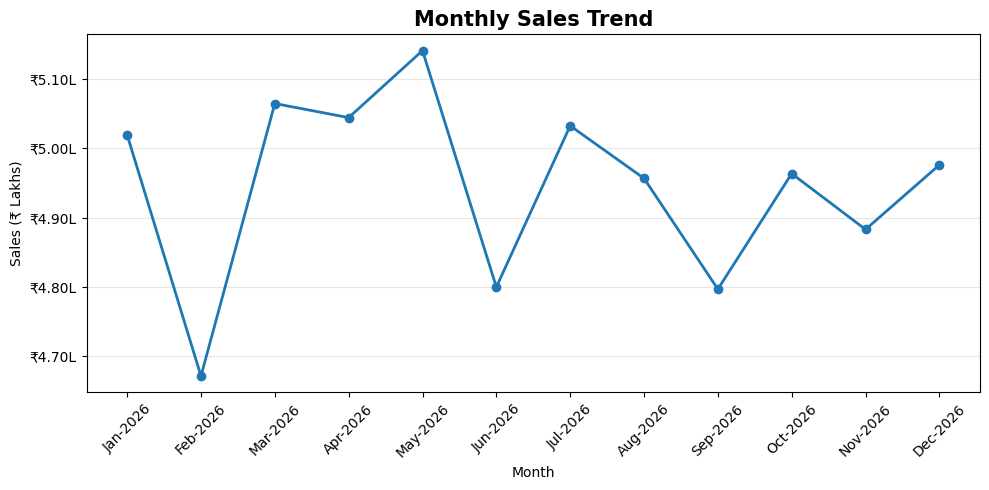

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_sales["Month_Label"],
    monthly_sales["Total_Sales"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Sales Trend", fontsize=15, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Sales (₹ Lakhs)")
plt.xticks(rotation=45)

# Display Y-axis in Lakhs
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"₹{x/100000:.2f}L")
)

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

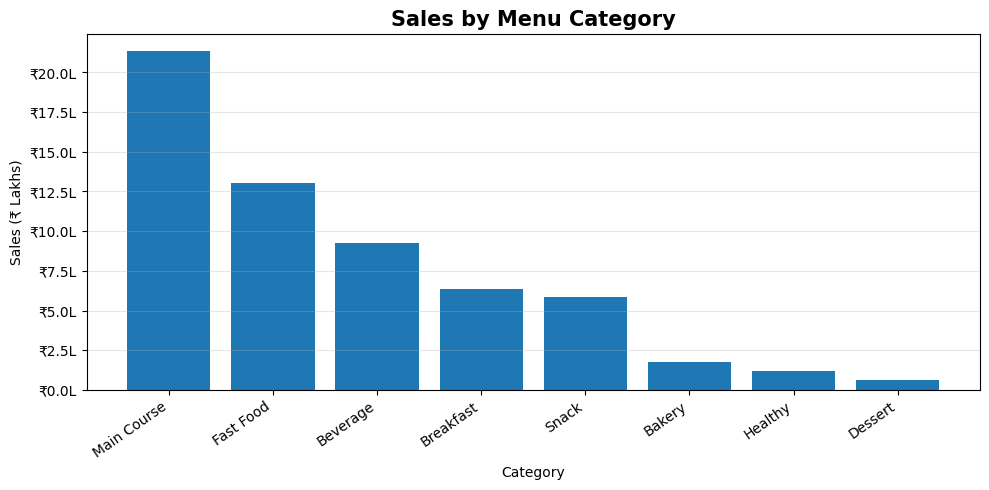

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Sales by category from Data Warehouse
category_sales = pd.read_sql_query("""
    SELECT
        m.Category,
        SUM(f.Sales_Amount) AS Total_Sales
    FROM Fact_Canteen_Sales f
    JOIN Dim_Menu_Item m
        ON f.Menu_Item_ID = m.Menu_Item_ID
    GROUP BY m.Category
    ORDER BY Total_Sales DESC
""", conn)

plt.figure(figsize=(10, 5))

plt.bar(
    category_sales["Category"],
    category_sales["Total_Sales"]
)

plt.title("Sales by Menu Category", fontsize=15, fontweight="bold")
plt.xlabel("Category")
plt.ylabel("Sales (₹ Lakhs)")
plt.xticks(rotation=35, ha="right")

# Convert ₹ to Lakhs
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"₹{x/100000:.1f}L")
)

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

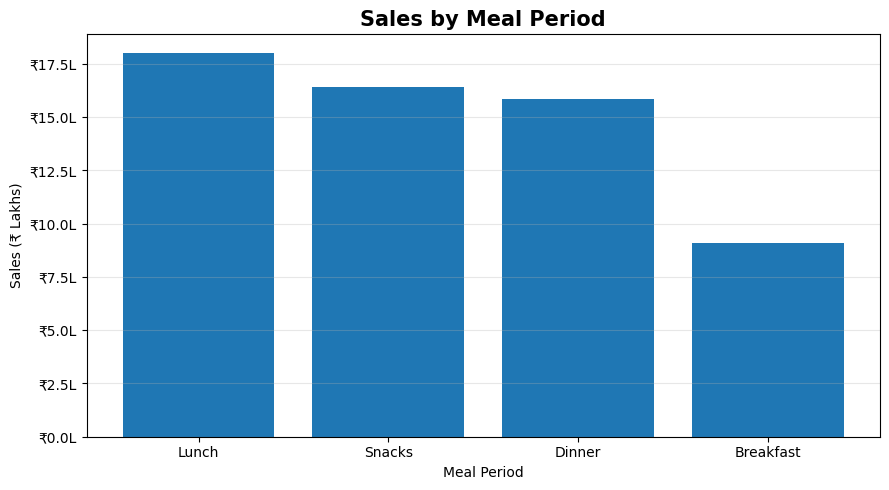

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Sales by meal period from Data Warehouse
meal_sales = pd.read_sql_query("""
    SELECT
        t.Meal_Period,
        SUM(f.Sales_Amount) AS Total_Sales
    FROM Fact_Canteen_Sales f
    JOIN Dim_Time t
        ON f.Time_ID = t.Time_ID
    GROUP BY t.Meal_Period
    ORDER BY Total_Sales DESC
""", conn)

plt.figure(figsize=(9, 5))

plt.bar(
    meal_sales["Meal_Period"],
    meal_sales["Total_Sales"]
)

plt.title("Sales by Meal Period", fontsize=15, fontweight="bold")
plt.xlabel("Meal Period")
plt.ylabel("Sales (₹ Lakhs)")

# Convert ₹ to Lakhs
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"₹{x/100000:.1f}L")
)

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()